<a href="https://colab.research.google.com/github/Divyaa2601/Predictive-Student-Success-Monitoring-System/blob/main/notebooks/02_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Student Success Monitoring System

## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the synthetic student
academic dataset generated for the Predictive Student Success Monitoring System.

### Objectives

- Understand the structure and characteristics of the dataset.
- Examine academic risk distribution.
- Identify missing values and data quality issues.
- Analyze distributions of academic and engagement features.
- Study relationships between student features and academic risk.
- Identify correlations among numerical variables.
- Analyze deliberately introduced edge cases.
- Generate insights for preprocessing and machine learning model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
url = (
    "https://raw.githubusercontent.com/"
    "Divyaa2601/"
    "Predictive-Student-Success-Monitoring-System/"
    "main/data/student_success_dataset.csv"
)

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (2000, 15)


In [4]:
df.head()

,student_id,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,final_score,risk_level,edge_case_type
0,STU0001,4,6.13,64.9,60.5,56.8,62.3,66.0,51.3,10.4,6.1,1,41.5,High,normal
1,STU0002,4,7.19,52.5,55.7,66.4,68.5,67.7,45.2,5.1,2.7,6,58.9,Medium,normal
2,STU0003,5,6.40,52.1,53.8,55.9,63.4,65.4,32.3,12.0,2.3,0,48.4,Medium,normal
3,STU0004,6,6.86,74.9,64.1,42.2,77.8,52.2,52.7,10.5,4.8,5,54.5,Medium,normal
4,STU0005,4,9.26,74.4,82.3,64.9,78.2,72.3,71.1,9.9,9.3,4,70.7,Low,normal


In [5]:
print("Number of students:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of students: 2000
Number of columns: 15

Column names:
1. student_id
2. semester
3. previous_gpa
4. attendance_pct
5. internal_1
6. internal_2
7. assignment_avg
8. assignment_completion_pct
9. quiz_avg
10. study_hours_weekly
11. class_participation
12. late_submissions
13. final_score
14. risk_level
15. edge_case_type


In [6]:
print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 2000 non-null   object 
 1   semester                   2000 non-null   int64  
 2   previous_gpa               2000 non-null   float64
 3   attendance_pct             2000 non-null   float64
 4   internal_1                 2000 non-null   float64
 5   internal_2                 2000 non-null   float64
 6   assignment_avg             2000 non-null   float64
 7   assignment_completion_pct  2000 non-null   float64
 8   quiz_avg                   1940 non-null   float64
 9   study_hours_weekly         1940 non-null   float64
 10  class_participation        1940 non-null   float64
 11  late_submissions           2000 non-null   int64  
 12  final_score                2000 non-null   float64
 13  risk_level                

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
semester,2000.0,4.518500,1.116370,3.00,4.000,5.00,6.000,6.0
previous_gpa,2000.0,7.137575,1.487937,2.59,6.120,7.18,8.240,10.0
attendance_pct,2000.0,73.561494,14.918787,26.10,63.400,74.60,84.700,100.0
internal_1,2000.0,63.290233,18.427006,0.00,50.075,63.70,77.500,100.0
internal_2,2000.0,61.422528,20.565345,0.00,45.900,61.95,77.625,100.0
assignment_avg,2000.0,65.022573,18.239994,14.60,51.775,65.70,78.200,100.0
assignment_completion_pct,2000.0,68.871168,16.681705,17.40,57.500,70.05,81.300,100.0
quiz_avg,1940.0,58.021451,19.382851,0.00,45.000,57.80,72.100,100.0
study_hours_weekly,1940.0,11.454991,4.540623,0.00,8.300,11.80,14.800,24.4
class_participation,1940.0,5.293038,2.299219,0.00,3.800,5.40,6.900,10.0


In [8]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary

,Missing Values,Percentage (%)
student_id,0,0.0
semester,0,0.0
previous_gpa,0,0.0
attendance_pct,0,0.0
internal_1,0,0.0
internal_2,0,0.0
assignment_avg,0,0.0
assignment_completion_pct,0,0.0
quiz_avg,60,3.0
study_hours_weekly,60,3.0


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
risk_counts = df["risk_level"].value_counts()

risk_percentage = (
    df["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

risk_summary = pd.DataFrame({
    "Student Count": risk_counts,
    "Percentage (%)": risk_percentage
})

risk_summary

,Student Count,Percentage (%)
risk_level,,
Low,1199,59.95
Medium,500,25.00
High,301,15.05


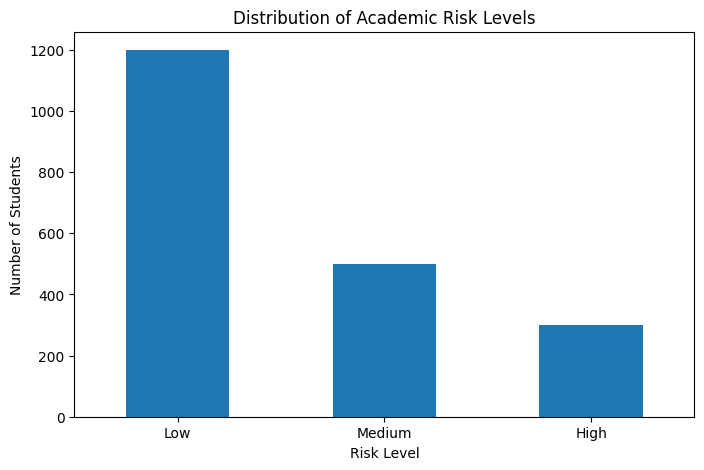

In [11]:
risk_order = ["Low", "Medium", "High"]

df["risk_level"].value_counts() \
    .reindex(risk_order) \
    .plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Academic Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

### Observation

The dataset contains students belonging to three academic risk categories.
Approximately 60% of the students belong to the Low Risk category, while
25% belong to Medium Risk and 15% belong to High Risk.

The distribution represents a moderately imbalanced academic monitoring
scenario in which most students perform satisfactorily while a smaller
proportion require academic intervention.

The High Risk class is sufficiently represented for initial machine learning
experiments. Therefore, class-sensitive evaluation metrics such as precision,
recall and F1-score will be considered in addition to overall accuracy.

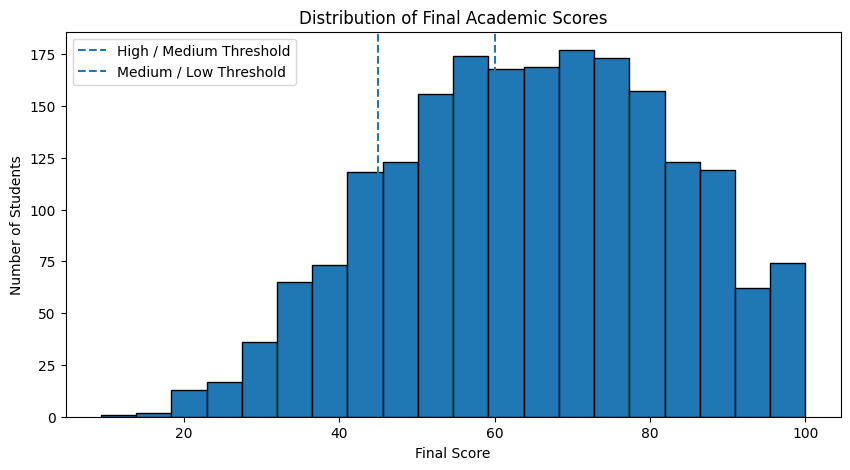

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["final_score"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    45,
    linestyle="--",
    label="High / Medium Threshold"
)

plt.axvline(
    60,
    linestyle="--",
    label="Medium / Low Threshold"
)

plt.title("Distribution of Final Academic Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.legend()

plt.show()

### Target Leakage Consideration

The `risk_level` variable was derived from the student's final academic score:

- **High Risk:** Final Score < 45
- **Medium Risk:** Final Score between 45 and 59.9
- **Low Risk:** Final Score >= 60

Therefore, `final_score` will **not be included as an input feature during
machine learning model training**, since doing so would introduce target
leakage and artificially inflate model performance.

The model will instead predict academic risk using information available
during the semester, such as attendance, internal assessment performance,
assignments, quizzes, previous GPA and engagement indicators.

In [13]:
risk_order = ["Low", "Medium", "High"]

Average Attendance by Risk Level:
risk_level
Low       77.57
Medium    70.06
High      63.40
Name: attendance_pct, dtype: float64


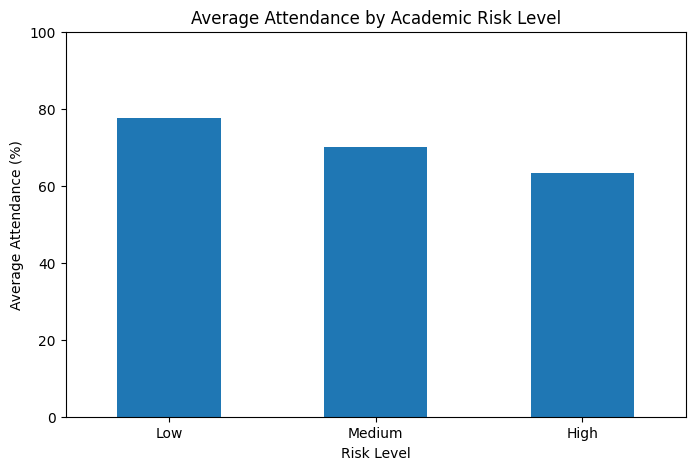

In [14]:
attendance_by_risk = (
    df.groupby("risk_level")["attendance_pct"]
    .mean()
    .reindex(risk_order)
)

print("Average Attendance by Risk Level:")
print(attendance_by_risk.round(2))

attendance_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Attendance by Academic Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Attendance (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

### Attendance Observation

Attendance shows a relationship with academic risk. Students in higher-risk
categories tend to have lower average attendance compared with students in
the Low Risk category.

However, attendance alone cannot determine academic success because the
dataset also contains edge cases such as students with low attendance but
strong academic performance and students with high attendance but poor
academic performance.

Average Previous GPA by Risk Level:
risk_level
Low       7.81
Medium    6.52
High      5.48
Name: previous_gpa, dtype: float64


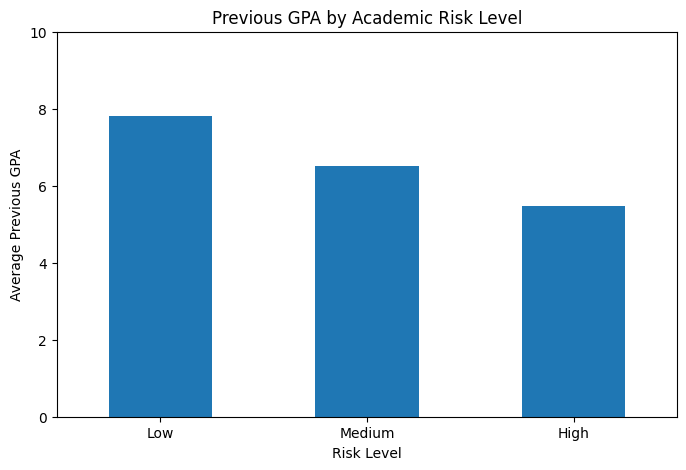

In [15]:
gpa_by_risk = (
    df.groupby("risk_level")["previous_gpa"]
    .mean()
    .reindex(risk_order)
)

print("Average Previous GPA by Risk Level:")
print(gpa_by_risk.round(2))

gpa_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Previous GPA by Academic Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Previous GPA")
plt.xticks(rotation=0)
plt.ylim(0, 10)
plt.show()

### Previous GPA Observation

Previous GPA provides information about a student's historical academic
performance. Students classified as High Risk generally show lower previous
GPA values, while Low Risk students tend to have stronger historical
performance.

However, previous GPA should not be considered independently because student
performance can improve or decline during the current semester.

Average Internal Marks by Risk Level:
            internal_1  internal_2
risk_level                        
Low              71.61       72.69
Medium           55.15       49.84
High             43.67       35.78


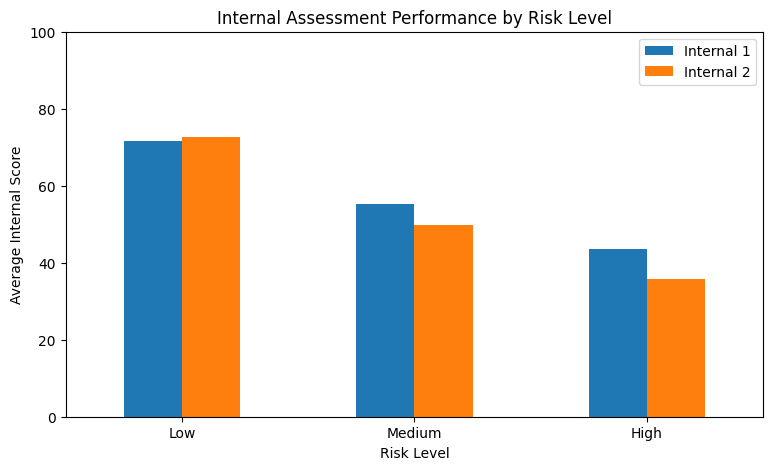

In [16]:
internal_by_risk = (
    df.groupby("risk_level")[["internal_1", "internal_2"]]
    .mean()
    .reindex(risk_order)
)

print("Average Internal Marks by Risk Level:")
print(internal_by_risk.round(2))

internal_by_risk.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Internal Assessment Performance by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Internal Score")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(["Internal 1", "Internal 2"])
plt.show()

### Internal Assessment Observation

Internal assessment performance varies across academic risk categories.
Students in the High Risk category generally obtain lower internal assessment
scores, whereas Low Risk students tend to achieve higher scores.

Using multiple internal assessments also provides information about changes
in performance during the semester, allowing the system to capture patterns
such as improvement or decline.

In [17]:
df["internal_change"] = (
    df["internal_2"] - df["internal_1"]
)

df[
    [
        "student_id",
        "internal_1",
        "internal_2",
        "internal_change"
    ]
].head(10)

,student_id,internal_1,internal_2,internal_change
0,STU0001,60.500000,56.800000,-3.700000
1,STU0002,55.700000,66.400000,10.700000
2,STU0003,53.800000,55.900000,2.100000
3,STU0004,64.100000,42.200000,-21.900000
4,STU0005,82.300000,64.900000,-17.400000
5,STU0006,79.400000,82.500000,3.100000
6,STU0007,75.241837,79.273181,4.031344
7,STU0008,39.400000,20.900000,-18.500000
8,STU0009,56.300000,37.900000,-18.400000
9,STU0010,49.300000,41.000000,-8.300000


Average Internal Performance Change:
risk_level
Low       1.08
Medium   -5.31
High     -7.89
Name: internal_change, dtype: float64


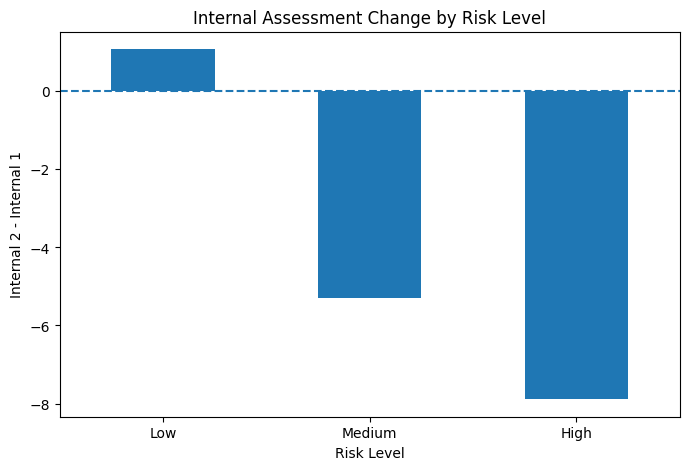

In [18]:
change_by_risk = (
    df.groupby("risk_level")["internal_change"]
    .mean()
    .reindex(risk_order)
)

print("Average Internal Performance Change:")
print(change_by_risk.round(2))

change_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.axhline(0, linestyle="--")

plt.title("Internal Assessment Change by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Internal 2 - Internal 1")
plt.xticks(rotation=0)

plt.show()

Assignment Statistics by Risk Level:
            assignment_avg  assignment_completion_pct
risk_level                                           
Low                  73.20                      74.65
Medium               56.32                      62.91
High                 46.93                      55.73


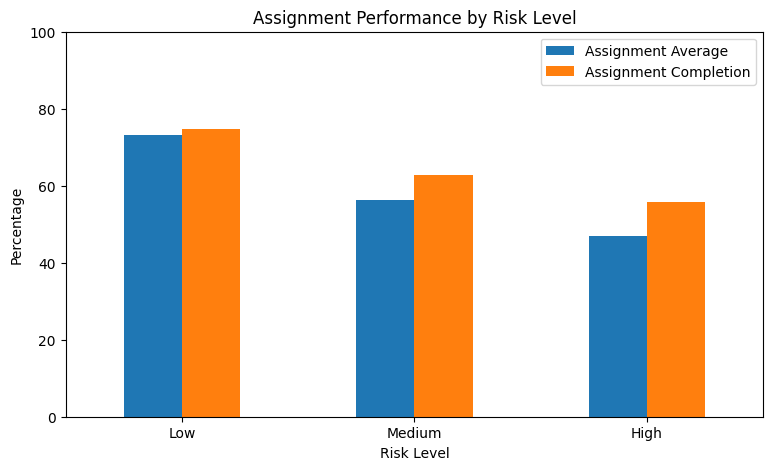

In [19]:
assignment_by_risk = (
    df.groupby("risk_level")[
        [
            "assignment_avg",
            "assignment_completion_pct"
        ]
    ]
    .mean()
    .reindex(risk_order)
)

print("Assignment Statistics by Risk Level:")
print(assignment_by_risk.round(2))

assignment_by_risk.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Assignment Performance by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend([
    "Assignment Average",
    "Assignment Completion"
])

plt.show()

### Assignment Observation

Assignment performance and completion rates provide additional indicators of
student academic engagement. Higher-risk students tend to demonstrate weaker
assignment performance or lower completion rates compared with lower-risk
students.

These variables can help the intervention engine distinguish between
performance-related difficulties and incomplete academic work.

Average Quiz Score by Risk Level:
risk_level
Low       66.88
Medium    49.19
High      36.77
Name: quiz_avg, dtype: float64


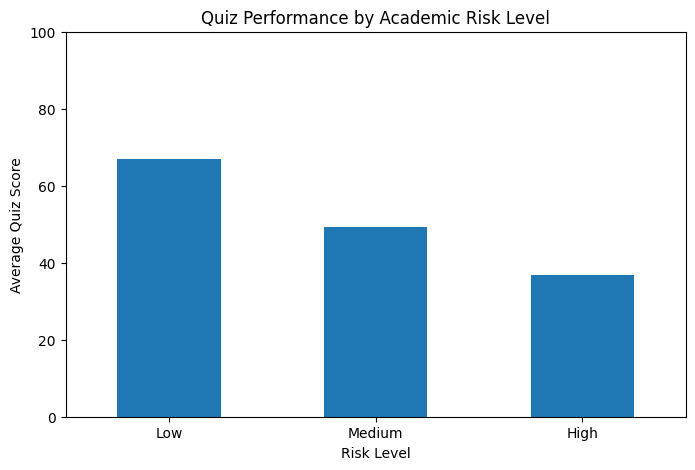

In [20]:
quiz_by_risk = (
    df.groupby("risk_level")["quiz_avg"]
    .mean()
    .reindex(risk_order)
)

print("Average Quiz Score by Risk Level:")
print(quiz_by_risk.round(2))

quiz_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Quiz Performance by Academic Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Quiz Score")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

Average Weekly Study Hours:
risk_level
Low       12.70
Medium    10.31
High       8.40
Name: study_hours_weekly, dtype: float64


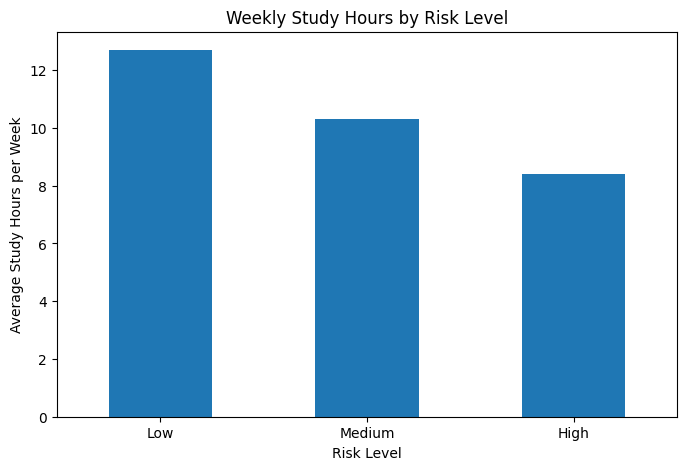

In [21]:
study_by_risk = (
    df.groupby("risk_level")["study_hours_weekly"]
    .mean()
    .reindex(risk_order)
)

print("Average Weekly Study Hours:")
print(study_by_risk.round(2))

study_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Weekly Study Hours by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Study Hours per Week")
plt.xticks(rotation=0)

plt.show()

Average Class Participation:
risk_level
Low       5.87
Medium    4.75
High      3.90
Name: class_participation, dtype: float64


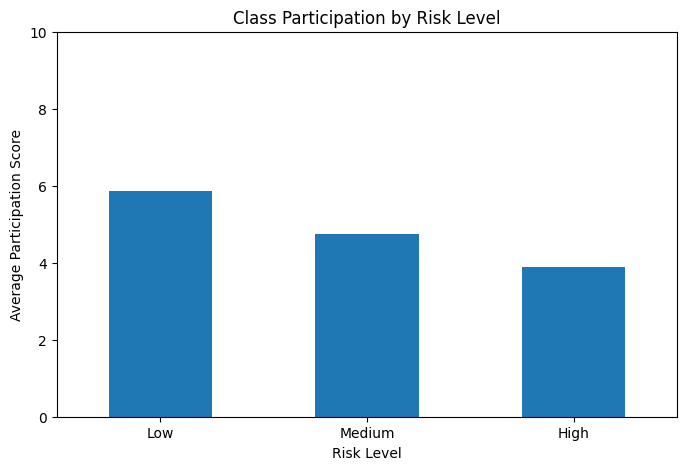

In [22]:
participation_by_risk = (
    df.groupby("risk_level")["class_participation"]
    .mean()
    .reindex(risk_order)
)

print("Average Class Participation:")
print(participation_by_risk.round(2))

participation_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Participation by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Participation Score")
plt.xticks(rotation=0)
plt.ylim(0, 10)

plt.show()

Average Late Submissions:
risk_level
Low       2.79
Medium    4.01
High      4.33
Name: late_submissions, dtype: float64


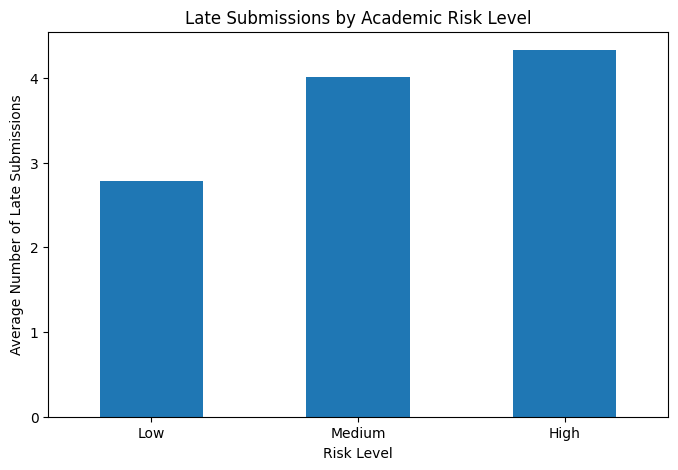

In [23]:
late_by_risk = (
    df.groupby("risk_level")["late_submissions"]
    .mean()
    .reindex(risk_order)
)

print("Average Late Submissions:")
print(late_by_risk.round(2))

late_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Submissions by Academic Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Number of Late Submissions")
plt.xticks(rotation=0)

plt.show()

## Overall Feature Analysis Findings

The exploratory analysis shows clear differences in academic and engagement
characteristics across the three risk categories.

- Average attendance decreases from 77.57% for Low Risk students to 63.40%
  for High Risk students.
- Previous GPA decreases from 7.81 in the Low Risk group to 5.48 in the
  High Risk group, indicating that historical academic performance provides
  useful predictive information.
- Internal assessment performance shows a strong relationship with academic
  risk. High Risk students have substantially lower Internal 1 and Internal 2
  scores than Low Risk students.
- Performance trend is also important. Low Risk students show a small average
  improvement of +1.08 marks between the two internal assessments, while
  Medium and High Risk students show average declines of -5.31 and -7.89
  marks respectively.
- Assignment average and assignment completion rates decrease as academic
  risk increases.
- Average quiz performance decreases considerably across the Low, Medium and
  High Risk categories.
- High Risk students report fewer weekly study hours and lower classroom
  participation on average.
- Late submissions increase with academic risk, although the difference
  between Medium and High Risk students is relatively small.

These observations suggest that academic risk is associated with a combination
of historical performance, current assessments, attendance, assignment
behavior and engagement rather than any single factor.

In [24]:
numeric_features = [
    "semester",
    "previous_gpa",
    "attendance_pct",
    "internal_1",
    "internal_2",
    "assignment_avg",
    "assignment_completion_pct",
    "quiz_avg",
    "study_hours_weekly",
    "class_participation",
    "late_submissions",
    "internal_change",
    "final_score"
]

correlation_matrix = df[numeric_features].corr()

correlation_matrix.round(2)

,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,internal_change,final_score
semester,1.00,-0.04,-0.03,-0.05,-0.03,-0.01,-0.02,-0.04,-0.03,-0.01,-0.02,0.02,-0.04
previous_gpa,-0.04,1.00,0.44,0.63,0.62,0.60,0.47,0.60,0.39,0.37,-0.26,0.08,0.68
attendance_pct,-0.03,0.44,1.00,0.34,0.33,0.49,0.60,0.37,0.56,0.55,-0.34,0.04,0.43
internal_1,-0.05,0.63,0.34,1.00,0.69,0.51,0.42,0.56,0.34,0.30,-0.23,-0.27,0.69
internal_2,-0.03,0.62,0.33,0.69,1.00,0.57,0.42,0.63,0.32,0.34,-0.27,0.51,0.80
assignment_avg,-0.01,0.60,0.49,0.51,0.57,1.00,0.61,0.48,0.49,0.48,-0.40,0.15,0.66
assignment_completion_pct,-0.02,0.47,0.60,0.42,0.42,0.61,1.00,0.38,0.59,0.58,-0.45,0.06,0.52
quiz_avg,-0.04,0.60,0.37,0.56,0.63,0.48,0.38,1.00,0.29,0.30,-0.24,0.17,0.67
study_hours_weekly,-0.03,0.39,0.56,0.34,0.32,0.49,0.59,0.29,1.00,0.60,-0.34,0.03,0.43
class_participation,-0.01,0.37,0.55,0.30,0.34,0.48,0.58,0.30,0.60,1.00,-0.33,0.09,0.39


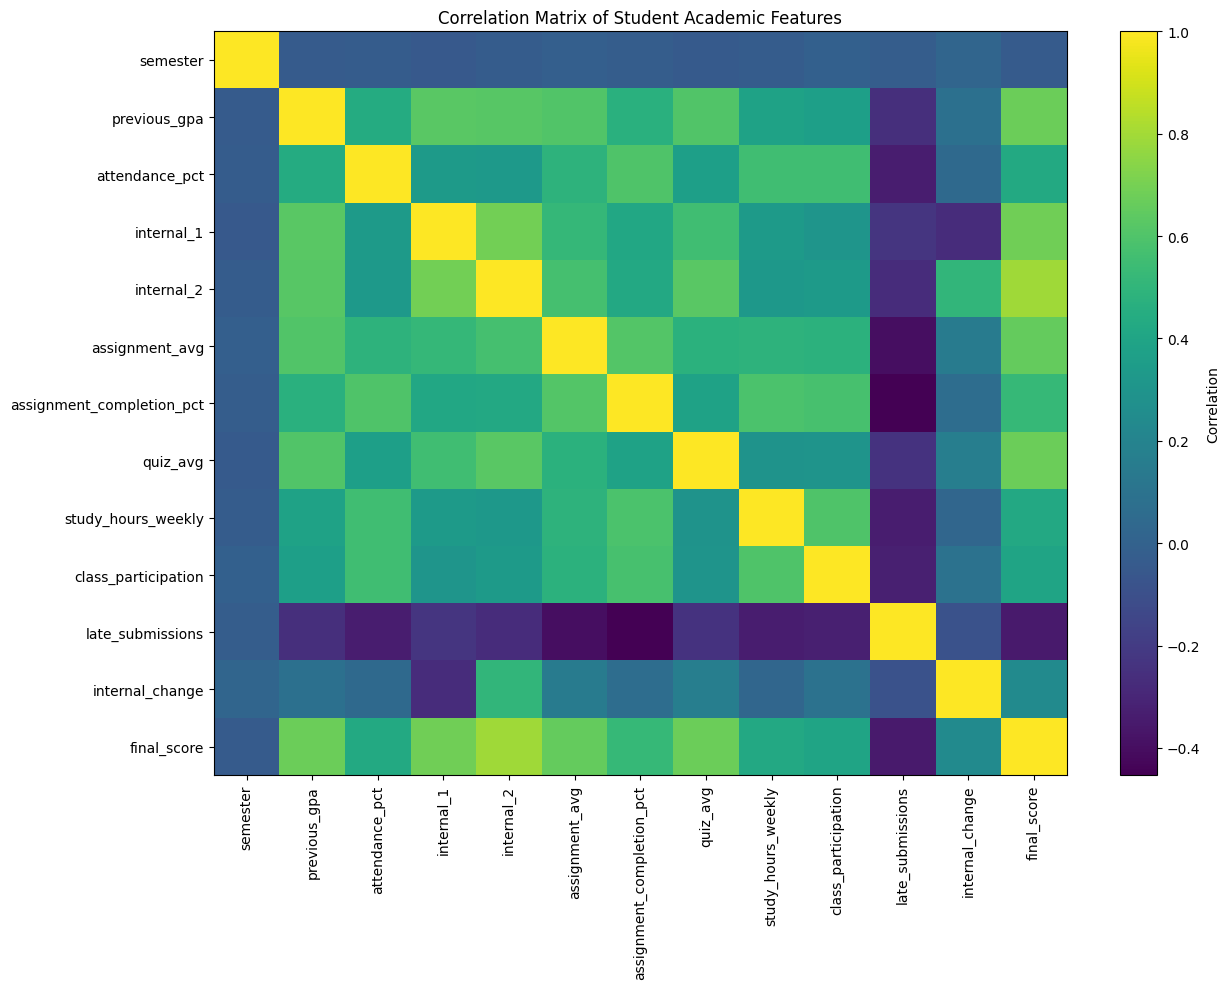

In [25]:
plt.figure(figsize=(13, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=90
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.title("Correlation Matrix of Student Academic Features")
plt.tight_layout()

plt.show()

In [26]:
final_score_corr = (
    correlation_matrix["final_score"]
    .drop("final_score")
    .sort_values(ascending=False)
)

print("Correlation of Features with Final Score:")
print(final_score_corr.round(3))

Correlation of Features with Final Score:
internal_2                   0.795
internal_1                   0.686
previous_gpa                 0.676
quiz_avg                     0.672
assignment_avg               0.659
assignment_completion_pct    0.522
attendance_pct               0.428
study_hours_weekly           0.426
class_participation          0.395
internal_change              0.241
semester                    -0.038
late_submissions            -0.350
Name: final_score, dtype: float64


### Correlation Analysis Observation

Internal Assessment 2 shows the strongest positive correlation with final
academic performance (0.795), followed by Internal Assessment 1 (0.686),
previous GPA (0.676), quiz performance (0.672), and assignment average
(0.659).

Attendance shows a moderate positive correlation (0.428), indicating that
attendance contributes useful information but is not sufficient by itself
to determine academic performance.

Late submissions show a negative correlation (-0.350), suggesting that
frequent delayed submissions are associated with weaker academic outcomes.

Semester has almost no linear relationship with final score (-0.038), while
the engineered internal assessment change feature shows a relatively weak
positive correlation (0.241).

These findings support the use of multiple academic and engagement indicators
rather than relying on attendance alone for student risk prediction.

In [27]:
edge_counts = df["edge_case_type"].value_counts()

print("Edge Case Distribution:")
print(edge_counts)

Edge Case Distribution:
edge_case_type
normal                             1760
low_engagement_high_performance      40
low_attendance_high_performance      40
sudden_decline                       40
assignment_problem                   40
sudden_improvement                   40
high_attendance_low_performance      40
Name: count, dtype: int64


In [28]:
edge_risk = pd.crosstab(
    df["edge_case_type"],
    df["risk_level"]
)

edge_risk

risk_level,High,Low,Medium
edge_case_type,,,
assignment_problem,4,6,30
high_attendance_low_performance,22,0,18
low_attendance_high_performance,0,40,0
low_engagement_high_performance,0,40,0
normal,258,1075,427
sudden_decline,17,1,22
sudden_improvement,0,37,3


In [32]:
edge_risk_percentage = pd.crosstab(
    df["edge_case_type"],
    df["risk_level"],
    normalize="index"
).mul(100).round(2)

edge_risk_percentage

risk_level,High,Low,Medium
edge_case_type,,,
assignment_problem,10.00,15.00,75.00
high_attendance_low_performance,55.00,0.00,45.00
low_attendance_high_performance,0.00,100.00,0.00
low_engagement_high_performance,0.00,100.00,0.00
normal,14.66,61.08,24.26
sudden_decline,42.50,2.50,55.00
sudden_improvement,0.00,92.50,7.50


### Edge Case Analysis Observation

The deliberately introduced edge cases demonstrate that individual academic
indicators should not be interpreted independently.

Students with high attendance but poor academic performance were primarily
classified as Medium or High Risk, demonstrating that high attendance alone
does not guarantee academic success.

Conversely, students with low attendance but strong academic performance were
classified as Low Risk, preventing attendance from becoming the sole
determinant of academic risk.

Students experiencing sudden academic decline were predominantly classified
as Medium or High Risk, whereas students showing sudden improvement were
primarily classified as Low Risk.

Students with assignment-related difficulties were concentrated mainly in the
Medium Risk category, indicating the need for targeted intervention without
automatically treating assignment difficulties as severe academic failure.

These edge cases increase the diversity of the synthetic dataset and provide
useful scenarios for evaluating the robustness of the prediction and
intervention components.

In [30]:
edge_students = df[
    df["edge_case_type"] != "normal"
]

edge_students[
    [
        "student_id",
        "attendance_pct",
        "previous_gpa",
        "internal_1",
        "internal_2",
        "assignment_avg",
        "quiz_avg",
        "final_score",
        "risk_level",
        "edge_case_type"
    ]
].head(20)

,student_id,attendance_pct,previous_gpa,internal_1,internal_2,assignment_avg,quiz_avg,final_score,risk_level,edge_case_type
6,STU0007,90.400000,8.86,75.241837,79.273181,74.000000,86.331065,91.4,Low,low_engagement_high_performance
33,STU0034,48.543669,6.77,75.714452,85.528327,97.093952,68.400000,79.3,Low,low_attendance_high_performance
36,STU0037,71.900000,8.30,92.550687,31.226436,35.778137,59.500000,45.3,Medium,sudden_decline
38,STU0039,84.135704,7.67,53.900000,54.200000,31.447061,65.700000,59.5,Medium,assignment_problem
50,STU0051,66.000000,7.14,94.393409,79.471748,42.000000,93.278501,83.1,Low,low_engagement_high_performance
60,STU0061,80.200000,5.73,36.929024,90.308069,75.800000,85.143974,68.9,Low,sudden_improvement
64,STU0065,75.200000,6.54,87.734139,95.542095,56.300000,91.598285,74.6,Low,low_engagement_high_performance
72,STU0073,55.561888,7.75,93.959260,92.319291,79.827594,63.700000,80.0,Low,low_attendance_high_performance
97,STU0098,73.900000,6.08,85.269256,79.546174,59.200000,83.121853,83.1,Low,low_engagement_high_performance
102,STU0103,74.700000,7.95,31.671519,75.257243,72.200000,80.683536,65.6,Low,sudden_improvement


In [31]:
for column in [
    "quiz_avg",
    "study_hours_weekly",
    "class_participation"
]:
    print(f"\nMissing values in {column} by risk level:")

    print(
        df[df[column].isnull()]
        ["risk_level"]
        .value_counts()
        .reindex(risk_order, fill_value=0)
    )


Missing values in quiz_avg by risk level:
risk_level
Low       29
Medium    17
High      14
Name: count, dtype: int64

Missing values in study_hours_weekly by risk level:
risk_level
Low       36
Medium    12
High      12
Name: count, dtype: int64

Missing values in class_participation by risk level:
risk_level
Low       37
Medium    16
High       7
Name: count, dtype: int64


# EDA Conclusions

The exploratory data analysis indicates that the synthetic dataset contains
meaningful academic and behavioral patterns suitable for the development of
the student risk prediction prototype.

Academic risk is associated with multiple factors including attendance,
previous GPA, internal assessment scores, assignment performance, quiz
performance, study engagement and submission behavior.

The difference between Internal Assessment 1 and Internal Assessment 2 also
shows potential as an engineered feature for representing improvement or
decline in academic performance.

The dataset contains a moderate class imbalance, with Low Risk students forming
the majority and High Risk students forming the minority. Therefore, model
evaluation will consider precision, recall and F1-score in addition to accuracy.

Missing values are intentionally present in selected engagement and assessment
features and will be handled during preprocessing rather than removed during
EDA.

The deliberately introduced edge cases provide additional scenarios for
evaluating whether the prediction system can handle unusual student behavior,
such as high attendance with poor academic performance or low attendance with
strong academic performance.

The `final_score` variable is retained for analysis and validation but will
not be provided to the classification models because the target `risk_level`
was derived from the final score.

Similarly, `student_id` and `edge_case_type` will not be used as predictive
features. The edge-case label will only be retained for model evaluation.

Overall, the dataset is considered suitable for proceeding to preprocessing,
feature engineering and machine learning model development.